# Single-cell activity scores and receptor expression in AMP T + F CTAP

Checks at the single-cell level that the ligand activity shifts seen in pseudobulk T-3 and T-7
Tph/Tfh cells of the `T + F` CTAP are not pseudobulk artifacts, then compares expression of the
matching receptors between T-3 and T-7.

## 1. Import

In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import scanpy.external as sce
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import cnsplots as cns
cns.settings.panel_label_fontname = "sans serif"

# Repo-relative paths (inputs: imports_stable/, outputs: analysis_outs/)
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/03_activity_inference_model"
os.makedirs(f"{OUTS_DIR}/inference_model_validation_AMP", exist_ok=True)


In [2]:
# import anndata and activity scores
rna = sc.read_h5ad(f"{IMPORTS_DIR}/external/AMP_2023/amp_2023_cd4_processed.h5ad")

In [3]:
# import single cell activity scores
scored_obs = pd.read_parquet(f"{IMPORTS_DIR}/SIG13/analysis_outs/inference_model_disease_sc/activity_scores_amp_2023.parquet")

# match indices of scored_obs with rna.obs and replace
scored_obs.set_index('cell_id', inplace=True)
scored_obs = scored_obs.loc[rna.obs_names]
rna.obs = scored_obs.copy()

## 2. Re-embed the T + F CTAP subset

`T + F` CTAP RA cells plus OA controls, re-embedded (HVGs, PCA, Harmony on `subject_id`, UMAP).

In [4]:
N_HVG = 3000
N_PCS = 50
N_NEIGHBORS = 50
MIN_CELLS_PER_GENE = 10   
BATCH_KEY = "subject_id"
BAD_GENE_PATTERN = r"^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT|TRA[VJ]|TRB[VDJ]|HBA[12]|^IG[HKL]|RP[1-9]+\-|^MTRNR"


def build_subset(adata):
    print(f"TF CTAP: {adata.n_obs} cells, {adata.obs[BATCH_KEY].nunique()} "
          f"{BATCH_KEY}s", flush=True)
    print(adata.obs["cluster_name"].value_counts().to_string(), flush=True)

    # filter for minimum cells
    sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)
    print(f"genes with >= {MIN_CELLS_PER_GENE} cells in subset: {adata.n_vars}",
          flush=True)

    # remove bad genes
    bad_genes = adata.var_names.str.contains(BAD_GENE_PATTERN)
    adata = adata[:, ~bad_genes].copy()
    print(f"bad genes removed: {bad_genes.sum()}", flush=True)

    # HVG / PCA / harmony operate on log1p_norm
    adata.X = adata.layers["log1p_norm"].copy()
    sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG)

    # scale and PCA
    scaled = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(scaled)
    sc.tl.pca(scaled, n_comps=N_PCS)
    adata.obsm["X_pca"] = scaled.obsm["X_pca"]

    sce.pp.harmony_integrate(adata, key=BATCH_KEY, basis="X_pca",
                             adjusted_basis="X_pca_harmony")

    sc.pp.neighbors(adata, n_neighbors=N_NEIGHBORS, use_rep="X_pca_harmony")
    sc.tl.umap(adata)
    print("re-embedding done", flush=True)
    return adata

In [5]:
rna_tf = build_subset(rna[rna.obs["CTAP"].isin(["T + F","control"])].copy())

TF CTAP: 17816 cells, 15 subject_ids
cluster_name
T-0: CD4+ IL7R+ memory         3046
T-1: CD4+ CD161+ memory        2577
T-4: CD4+ naive                2144
T-2: CD4+ IL7R+CCR5+ memory    1885
T-3: CD4+ IFNG- Tph/Tfh        1551
T-5: CD4+ GZMK+ memory         1415
T-9: CD4+ CD25-low Treg         964
T-6: CD4+ memory                915
T-10: CD4+ OX40+NR3C1+          812
T-12: CD4+ GNLY+                756
T-8: CD4+ CD25-high Treg        753
T-7: CD4+ IFNG+ Tph/Tfh         521
T-11: CD4+ CD146+ memory        477
genes with >= 10 cells in subset: 17725
bad genes removed: 351


/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-09-02 14:32:31,114 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-09-02 14:32:31,115 - harmonypy - INFO -   Parameters:
2026-09-02 14:32:31,115 - harmonypy - INFO -     max_iter_harmony: 10
2026-09-02 14:32:31,115 - harmonypy - INFO -     max_iter_kmeans: 20
2026-09-02 14:32:31,116 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-09-02 14:32:31,116 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-09-02 14:32:31,116 - harmonypy - INFO -     nclust: 100
2026-09-02 14:32:31,116 - harmonypy - INFO -     block_size: 0.05
2026-09-02 14:32:31,117 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-09-02 14:32:31,118 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-09-02 14:32:31,118 - harmonypy - INFO -     sig

re-embedding done


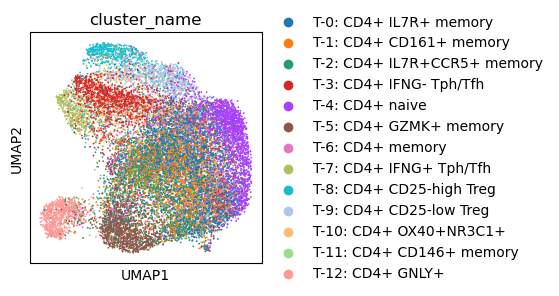

In [6]:
plt.rcParams['figure.figsize'] = (3,3)
sc.pl.umap(rna_tf, color=['cluster_name'])

## 3. Single-cell activity scores

Per-cell activity scores, `T + F` CTAP vs control cells, one figure per subset (T-7, T-3, T-4).
Brackets are cnsplots' default Mann-Whitney U test.

In [7]:
rna_tf_subset = rna_tf[rna_tf.obs['cluster_name'].isin(['T-7: CD4+ IFNG+ Tph/Tfh',
                                                        'T-3: CD4+ IFNG- Tph/Tfh',
                                                        'T-4: CD4+ naive',])].copy()

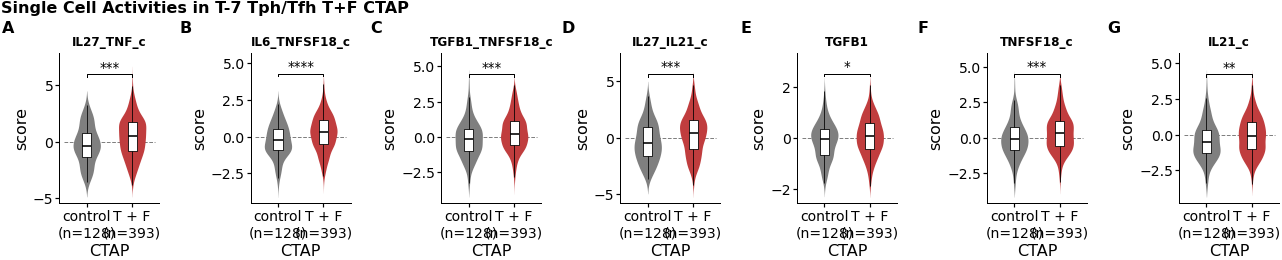

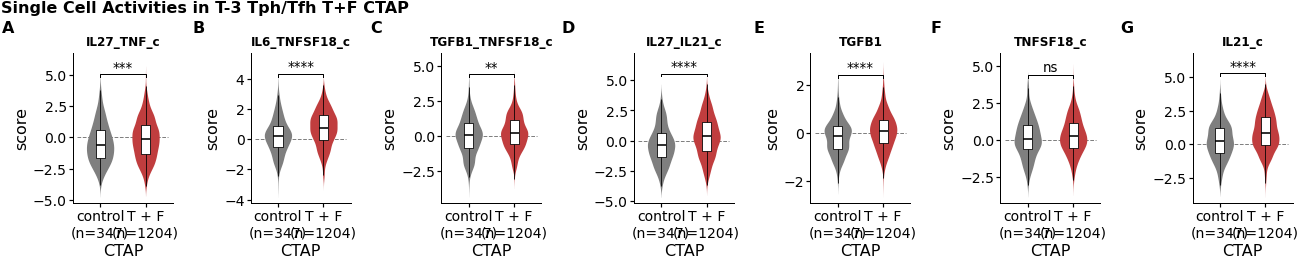

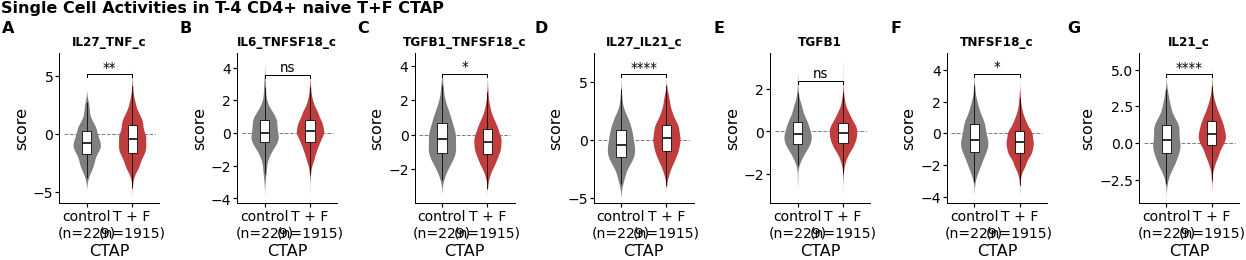

In [9]:
activities = ['activity_IL27_TNF_c', 'activity_IL6_TNFSF18_c','activity_TGFB1_TNFSF18_c','activity_IL27_IL21_c',
              'activity_TGFB1', 'activity_TNFSF18_c', 'activity_IL21_c',]

df = rna_tf_subset.obs[activities + ['cluster_name', 'CTAP']].copy()
df_long_all = df.melt(
    id_vars=['cluster_name', 'CTAP'],
    value_vars=activities,
    var_name='activity',
    value_name='score'
)

palette = sns.color_palette(["#7f7f7f", "#d62728"])
ctap_order = ["control", "T + F"]
panel_labels = "ABCDEFG"

# cluster -> (title label, file tag)
subsets = {'T-7: CD4+ IFNG+ Tph/Tfh': ("T-7 Tph/Tfh", "T7"),
           'T-3: CD4+ IFNG- Tph/Tfh': ("T-3 Tph/Tfh", "T3"),
           'T-4: CD4+ naive': ("T-4 CD4+ naive", "T4")}

for cluster, (label_name, tag) in subsets.items():
    df_long = df_long_all.query('cluster_name == @cluster')
    mp = cns.multipanel(max_width=1000, title=f"Single Cell Activities in {label_name} T+F CTAP",
                        title_fontweight="bold", loc="left")
    for label, activity in zip(panel_labels, activities):
        mp.panel(label, 50, 75)
        ax = cns.violinplot(
            df_long.query('activity == @activity'),
            x='CTAP', y='score', hue='CTAP',
            palette=palette, hue_order=ctap_order, order=ctap_order, pairs="all", add_count=True
        )
        title = activity.replace('activity_', '')
        ax.set_title(title, fontsize=6, fontweight="bold")
        ax.hlines(y=0, xmin=-0.5, xmax=1.5, colors='grey', linestyles='dashed', linewidth=0.5, zorder=0)
    cns.savefig(f"{OUTS_DIR}/inference_model_validation_AMP/sc_viz_TF_{tag}_cells.pdf")

## 4. Receptor expression, T-3 vs T-7

Donor pseudobulk (mean `log1p_norm`) of the matching receptors, `T + F` CTAP cells only. Grey lines
join the same donor. Paired Wilcoxon signed-rank test per receptor, BH-corrected across receptors.

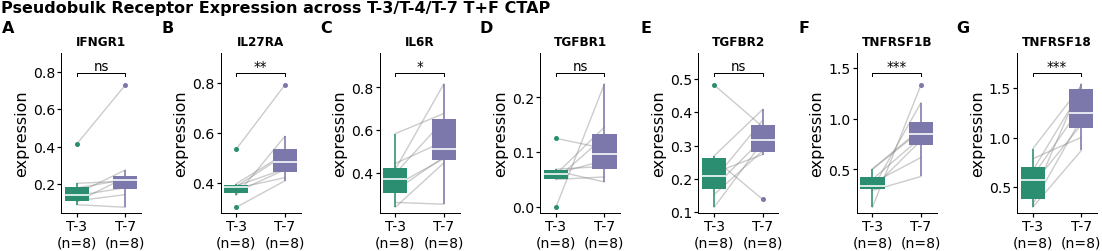

In [17]:
receptors = ['IFNGR1','IL27RA','IL6R','TGFBR1','TGFBR2','TNFRSF1B','TNFRSF18']

# pseudobulk per subject_id x cluster_name, restricted to T + F CTAP T-3 and T-7 cells
rna_tf_only = rna_tf_subset[rna_tf_subset.obs['CTAP'] == 'T + F'].copy()
rna_tf_only = rna_tf_only[rna_tf_only.obs['cluster_name'].isin(
    ['T-3: CD4+ IFNG- Tph/Tfh', 'T-7: CD4+ IFNG+ Tph/Tfh'])].copy()

rna_pseudobulk_tf = sc.get.aggregate(rna_tf_only, by=['subject_id', 'cluster_name'], func='mean', layer='log1p_norm')
rna_pseudobulk_tf.X = rna_pseudobulk_tf.layers['mean'].copy()

pb_tf_df = sc.get.obs_df(rna_pseudobulk_tf, keys=receptors).join(
    rna_pseudobulk_tf.obs[['subject_id', 'cluster_name']])

pb_tf_long = pb_tf_df.melt(
    id_vars=['subject_id', 'cluster_name'],
    value_vars=receptors,
    var_name='receptor', value_name='expression'
)

cluster_tags_tf = {'T-3: CD4+ IFNG- Tph/Tfh': 'T-3', 'T-7: CD4+ IFNG+ Tph/Tfh': 'T-7'}
pb_tf_long['cluster_tag'] = pb_tf_long['cluster_name'].map(cluster_tags_tf)

group_order_tf = ['T-3', 'T-7']
palette_tf = sns.color_palette(["#1B9E77FF", "#7570B3FF"])

mp = cns.multipanel(max_width=1000, title="Pseudobulk Receptor Expression across T-3/T-7 T+F CTAP",
                     title_fontweight="bold", loc="left")

for label, receptor in zip(panel_labels, receptors):
    mp.panel(label, 40, 80)
    sub = pb_tf_long.query('receptor == @receptor')

    ax = cns.boxplot(
        sub,
        x='cluster_tag', y='expression', hue='cluster_tag',
        palette=palette_tf, hue_order=group_order_tf, order=group_order_tf,
        pairs="all", add_count=True, showoutliers=True
    )

    # --- add paired lines connecting each subject across T-3/T-7 ---
    wide = sub.pivot(index='subject_id', columns='cluster_tag', values='expression')
    wide = wide[group_order_tf].dropna()  # only subjects present in both groups

    x_positions = np.arange(len(group_order_tf))  # [0, 1] matching order_tf
    for _, row in wide.iterrows():
        ax.plot(x_positions, row[group_order_tf].values,
                color='gray', alpha=0.4, linewidth=0.7, zorder=1)

    ax.set_title(receptor, fontsize=6, fontweight="bold")
    ax.tick_params(axis='x')
    ax.set_xlabel("")

cns.savefig(f"{OUTS_DIR}/inference_model_validation_AMP/pseudobulk_receptor_T3_T7_TFonly.pdf")

/tmp/ipykernel_2809754/2462268633.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['receptor', 'cluster_tag', 'subject_id'], as_index=False)['expression']
/tmp/ipykernel_2809754/2462268633.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for subject_id, sdf in sub.groupby('subject_id'):


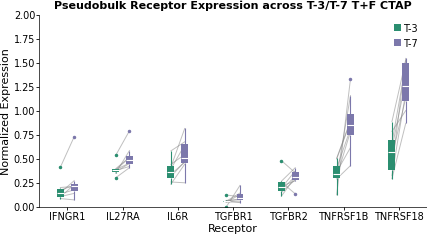

In [18]:
fig, ax = plt.subplots(figsize=(5, 2.5))
ax = cns.boxplot(
    pb_tf_long,
    x='receptor', y='expression', hue='cluster_tag',
    palette=palette_tf, order=receptors, hue_order=group_order_tf,
    showoutliers=True, gap = 0.5
)

# --- add grey lines connecting paired points (by subject_id) ---
n_hue = len(group_order_tf)
box_width = 0.5  # seaborn/cns default dodge width
offsets = -box_width / 2 + box_width / n_hue * (np.arange(n_hue) + 0.5)

# collapse to one value per receptor/cluster_tag/subject_id in case of duplicates
pb_agg = (
    pb_tf_long
    .groupby(['receptor', 'cluster_tag', 'subject_id'], as_index=False)['expression']
    .mean()
)

for receptor_idx, receptor in enumerate(receptors):
    sub = pb_agg[pb_agg['receptor'] == receptor]
    for subject_id, sdf in sub.groupby('subject_id'):
        sdf = sdf.set_index('cluster_tag')
        xs, ys = [], []
        for hue_idx, hue_val in enumerate(group_order_tf):
            if hue_val in sdf.index:
                xs.append(receptor_idx + offsets[hue_idx])
                ys.append(sdf.loc[hue_val, 'expression'])
        if len(xs) > 1:
            ax.plot(xs, ys, color='grey', linewidth=0.7, alpha=0.5, zorder=1)

ax.set_ylim(0,2.0)
ax.set_title("Pseudobulk Receptor Expression across T-3/T-7 T+F CTAP", fontsize=8, fontweight="bold")
ax.set_xlabel("Receptor")
ax.set_ylabel("Normalized Expression")
cns.savefig(f"{OUTS_DIR}/inference_model_validation_AMP/pseudobulk_receptor_T3_T7_TFonly_joint_boxplots.pdf")

In [14]:
wilcox_results = []
for receptor in receptors:
    sub = pb_tf_long.query('receptor == @receptor')
    groups = sub['cluster_tag'].unique()
    assert len(groups) == 2, f"{receptor} has {len(groups)} groups, expected 2"
    g1, g2 = groups

    # pivot so each row is one subject, one column per group
    wide = sub.pivot(index='subject_id', columns='cluster_tag', values='expression')

    # keep only subjects with data in both groups
    wide = wide[[g1, g2]].dropna()
    n_dropped = sub['subject_id'].nunique() - len(wide)

    x1 = wide[g1].values
    x2 = wide[g2].values

    stat, pval = wilcoxon(x1, x2)

    wilcox_results.append({
        'receptor': receptor,
        'group1': g1,
        'group2': g2,
        'n_pairs': len(wide),
        'n_dropped_unpaired': n_dropped,
        'median1': np.median(x1),
        'median2': np.median(x2),
        'median_diff': np.median(x1 - x2),
        'W_stat': stat,
        'p_value': pval,
    })

wilcox_df = pd.DataFrame(wilcox_results)
wilcox_df['p-adj'] = multipletests(wilcox_df['p_value'], method='fdr_bh')[1]
wilcox_df['reject'] = wilcox_df['p-adj'] < 0.05

wilcox_df

,receptor,group1,group2,n_pairs,n_dropped_unpaired,median1,median2,median_diff,W_stat,p_value,p-adj,reject
0,IFNGR1,T-3,T-7,8,0,0.142849,0.218983,-0.043743,2.0,0.023438,0.032813,True
1,IL27RA,T-3,T-7,8,0,0.383164,0.484351,-0.112727,0.0,0.007812,0.018229,True
2,IL6R,T-3,T-7,8,0,0.368390,0.509729,-0.140854,1.0,0.015625,0.027344,True
3,TGFBR1,T-3,T-7,8,0,0.060608,0.096085,-0.014644,7.0,0.148438,0.148438,False
4,TGFBR2,T-3,T-7,8,0,0.207835,0.316019,-0.135611,5.0,0.078125,0.091146,False
5,TNFRSF1B,T-3,T-7,8,0,0.338332,0.849707,-0.401240,0.0,0.007812,0.018229,True
6,TNFRSF18,T-3,T-7,8,0,0.568929,1.253797,-0.669875,0.0,0.007812,0.018229,True
